# 🏥 Gemelo Digital en Medicina
## Simulación de Paciente Virtual con Machine Learning
### Dataset: Pima Indians Diabetes Database (NIDDK)

---

**Objetivo:** Construir un gemelo digital simplificado de un paciente con riesgo de diabetes tipo 2, entrenar un modelo predictivo sobre datos clínicos reales, y simular cómo evolucionaría el paciente ante distintos escenarios clínicos (mejora, empeoramiento, intervención médica).

**Fuente del dataset:** National Institute of Diabetes and Digestive and Kidney Diseases (NIDDK). Disponible en el repositorio UCI Machine Learning Repository y Kaggle.

**Variables del dataset:**

| Variable | Descripción | Unidad |
|---|---|---|
| Pregnancies | Número de embarazos | — |
| Glucose | Concentración de glucosa en plasma (test oral 2h) | mg/dL |
| BloodPressure | Presión arterial diastólica | mmHg |
| SkinThickness | Grosor del pliegue cutáneo del tríceps | mm |
| Insulin | Insulina sérica a las 2h | mu U/ml |
| BMI | Índice de masa corporal | kg/m² |
| DiabetesPedigreeFunction | Función de pedigrí de diabetes (herencia genética) | — |
| Age | Edad | años |
| Outcome | Variable objetivo: 1 = diabética, 0 = no diabética | — |

---


## 1. Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score, roc_curve)
from sklearn.inspection import permutation_importance

# Estilo visual
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

print("✅ Librerías cargadas correctamente")

✅ Librerías cargadas correctamente


## 2. Carga y exploración inicial del dataset

In [2]:
df = pd.read_csv('diabetes.csv')

print(f"📊 Dimensiones del dataset: {df.shape[0]} pacientes × {df.shape[1]} variables")
print()
df.head(10)

📊 Dimensiones del dataset: 768 pacientes × 9 variables



,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


Distribución de clases:
  No diabéticas (0): 500 pacientes (65.1%)
  Diabéticas    (1): 268 pacientes (34.9%)



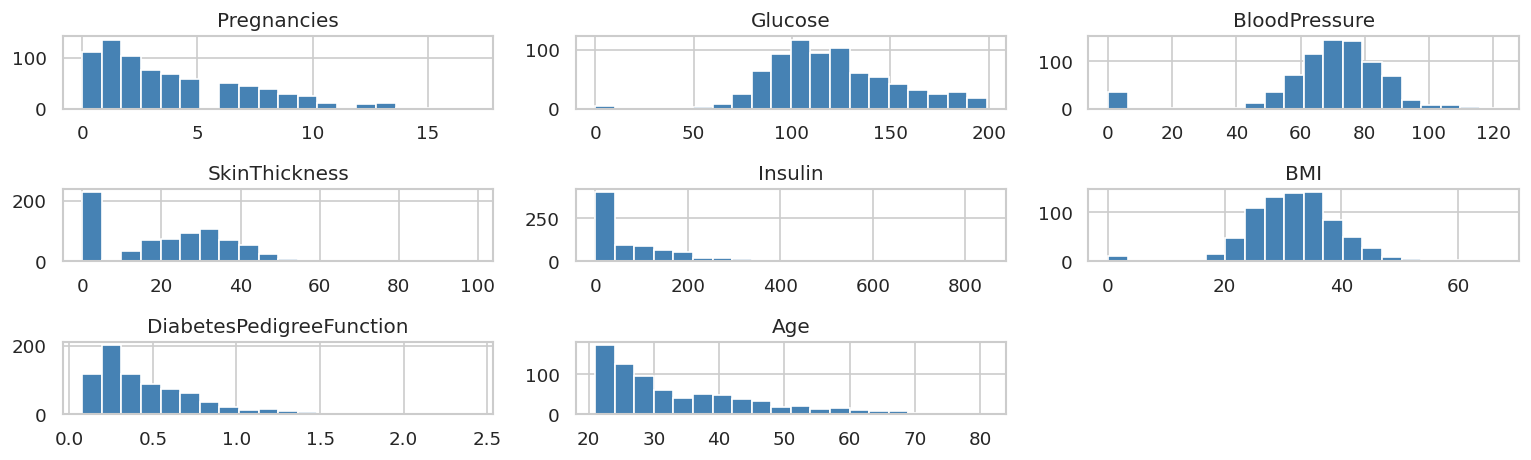

In [3]:
# Distribución de la variable objetivo
conteo = df['Outcome'].value_counts()
print("Distribución de clases:")
print(f"  No diabéticas (0): {conteo[0]} pacientes ({conteo[0]/len(df)*100:.1f}%)")
print(f"  Diabéticas    (1): {conteo[1]} pacientes ({conteo[1]/len(df)*100:.1f}%)")
print()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Distribución de la variable objetivo
axes[0].pie([conteo[0], conteo[1]], labels=['No diabética', 'Diabética'],
            autopct='%1.1f%%', colors=['#4CAF50', '#F44336'], startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[0].set_title('Distribución de la variable objetivo', fontsize=13, fontweight='bold')

# Histogramas de variables
df.drop('Outcome', axis=1).hist(ax=axes[1], bins=20, color='steelblue', edgecolor='white')
axes[1].set_title('Distribución de variables clínicas', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

## 3. Preprocesamiento: detección y tratamiento de valores anómalos

In [4]:
# Valores cero clínicamente imposibles
cols_invalidas = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print("🔍 Valores cero (clínicamente imposibles) por variable:")
ceros = (df[cols_invalidas] == 0).sum()
for col in cols_invalidas:
    n = (df[col] == 0).sum()
    pct = n / len(df) * 100
    print(f"  {col:<28}: {n:>3} ({pct:.1f}%)")

# Reemplazar por NaN e imputar con la mediana (más robusta que la media)
df[cols_invalidas] = df[cols_invalidas].replace(0, np.nan)
df.fillna(df.median(numeric_only=True), inplace=True)

print()
print("✅ Imputación completada con la mediana de cada variable")
print("   Valores nulos restantes:", df.isnull().sum().sum())

🔍 Valores cero (clínicamente imposibles) por variable:
  Glucose                     :   5 (0.7%)
  BloodPressure               :  35 (4.6%)
  SkinThickness               : 227 (29.6%)
  Insulin                     : 374 (48.7%)
  BMI                         :  11 (1.4%)

✅ Imputación completada con la mediana de cada variable
   Valores nulos restantes: 0


## 4. Análisis exploratorio avanzado

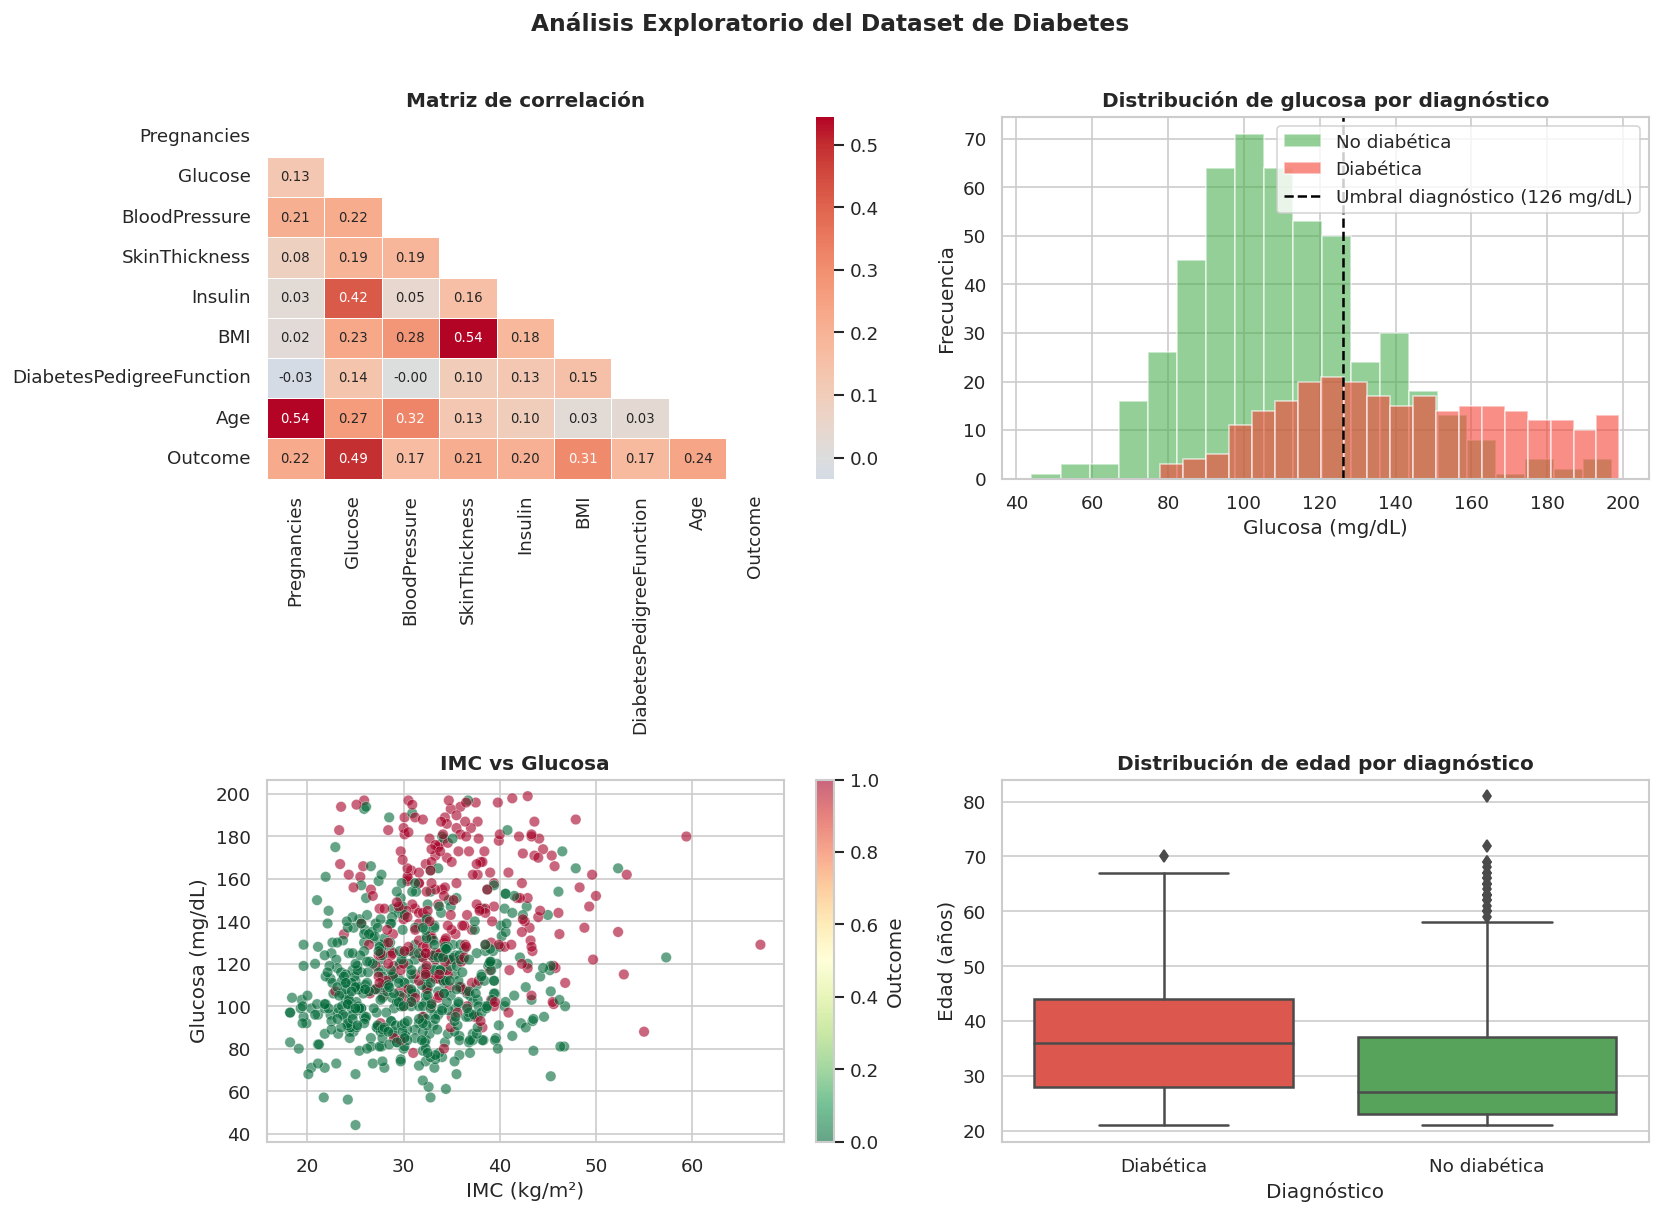

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 4.1 Matriz de correlación
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            mask=mask, ax=axes[0, 0], linewidths=0.5,
            annot_kws={"size": 8})
axes[0, 0].set_title('Matriz de correlación', fontsize=12, fontweight='bold')

# 4.2 Glucosa por outcome
for outcome, color, label in [(0, '#4CAF50', 'No diabética'), (1, '#F44336', 'Diabética')]:
    subset = df[df['Outcome'] == outcome]['Glucose']
    axes[0, 1].hist(subset, bins=20, alpha=0.6, color=color, label=label, edgecolor='white')
axes[0, 1].axvline(126, color='black', linestyle='--', linewidth=1.5, label='Umbral diagnóstico (126 mg/dL)')
axes[0, 1].set_xlabel('Glucosa (mg/dL)')
axes[0, 1].set_ylabel('Frecuencia')
axes[0, 1].set_title('Distribución de glucosa por diagnóstico', fontsize=12, fontweight='bold')
axes[0, 1].legend()

# 4.3 BMI vs Glucosa
scatter = axes[1, 0].scatter(df['BMI'], df['Glucose'], c=df['Outcome'],
                              cmap='RdYlGn_r', alpha=0.6, edgecolors='white', linewidths=0.3, s=40)
axes[1, 0].set_xlabel('IMC (kg/m²)')
axes[1, 0].set_ylabel('Glucosa (mg/dL)')
axes[1, 0].set_title('IMC vs Glucosa', fontsize=12, fontweight='bold')
plt.colorbar(scatter, ax=axes[1, 0], label='Outcome')

# 4.4 Boxplot edad por outcome
df_box = df[['Age', 'Outcome']].copy()
df_box['Diagnóstico'] = df_box['Outcome'].map({0: 'No diabética', 1: 'Diabética'})
sns.boxplot(data=df_box, x='Diagnóstico', y='Age', palette={'No diabética': '#4CAF50', 'Diabética': '#F44336'},
            ax=axes[1, 1])
axes[1, 1].set_title('Distribución de edad por diagnóstico', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Edad (años)')

plt.suptitle('Análisis Exploratorio del Dataset de Diabetes', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 5. Entrenamiento del modelo predictivo

In [6]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"  División del dataset:")
print(f"   Entrenamiento: {len(X_train)} muestras")
print(f"   Test:          {len(X_test)} muestras")

  División del dataset:
   Entrenamiento: 614 muestras
   Test:          154 muestras


In [7]:
# Random Forest con hiperparámetros optimizados
modelo = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42
)
modelo.fit(X_train, y_train)

# Evaluación
y_pred = modelo.predict(X_test)
y_prob = modelo.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

# Validación cruzada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(modelo, X, y, cv=cv, scoring='accuracy')

print("=" * 45)
print("      MÉTRICAS DE EVALUACIÓN DEL MODELO")
print("=" * 45)
print(f"  Accuracy (test set):      {acc:.4f} ({acc*100:.2f}%)")
print(f"  AUC-ROC:                  {auc:.4f}")
print(f"  CV Accuracy (5-fold):     {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print("=" * 45)
print()
print(" Reporte de clasificación:")
print(classification_report(y_test, y_pred, target_names=['No diabética', 'Diabética']))

      MÉTRICAS DE EVALUACIÓN DEL MODELO
  Accuracy (test set):      0.7403 (74.03%)
  AUC-ROC:                  0.8198
  CV Accuracy (5-fold):     0.7591 ± 0.0249

 Reporte de clasificación:
              precision    recall  f1-score   support

No diabética       0.83      0.75      0.79       100
   Diabética       0.61      0.72      0.66        54

    accuracy                           0.74       154
   macro avg       0.72      0.74      0.73       154
weighted avg       0.75      0.74      0.74       154



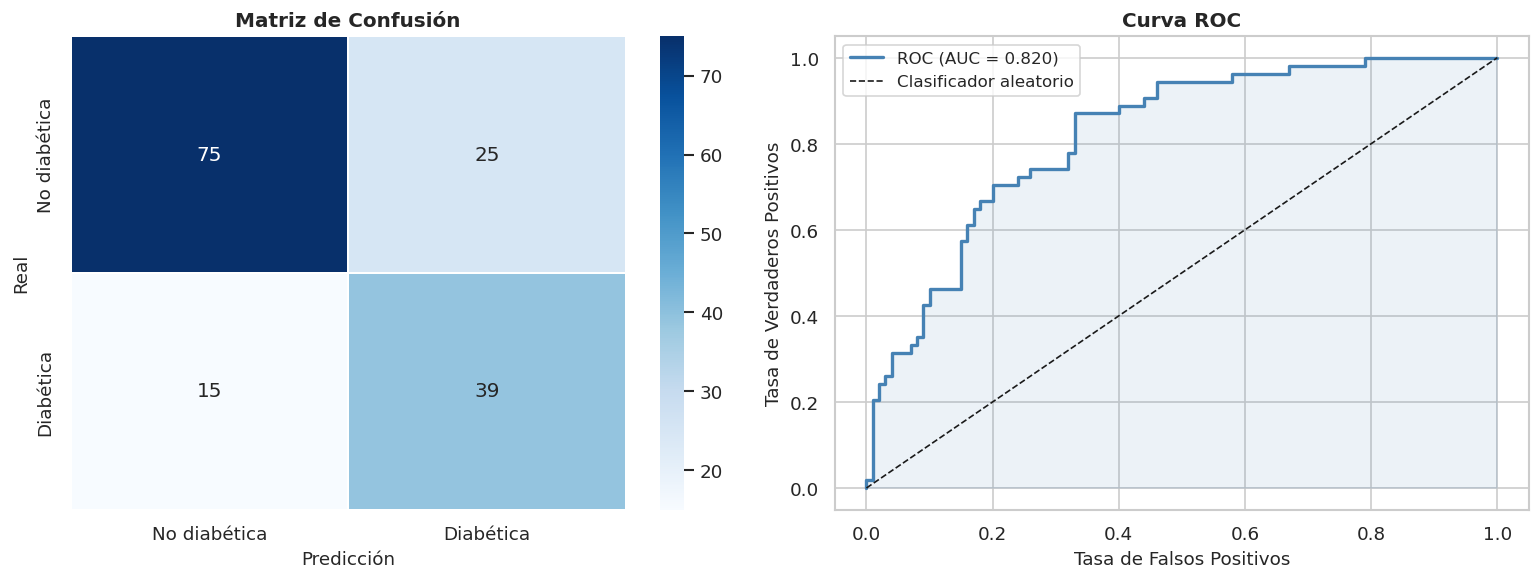

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No diabética', 'Diabética'],
            yticklabels=['No diabética', 'Diabética'],
            linewidths=1, linecolor='white')
axes[0].set_xlabel('Predicción', fontsize=11)
axes[0].set_ylabel('Real', fontsize=11)
axes[0].set_title('Matriz de Confusión', fontsize=12, fontweight='bold')

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, color='steelblue', lw=2, label=f'ROC (AUC = {auc:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Clasificador aleatorio')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='steelblue')
axes[1].set_xlabel('Tasa de Falsos Positivos', fontsize=11)
axes[1].set_ylabel('Tasa de Verdaderos Positivos', fontsize=11)
axes[1].set_title('Curva ROC', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

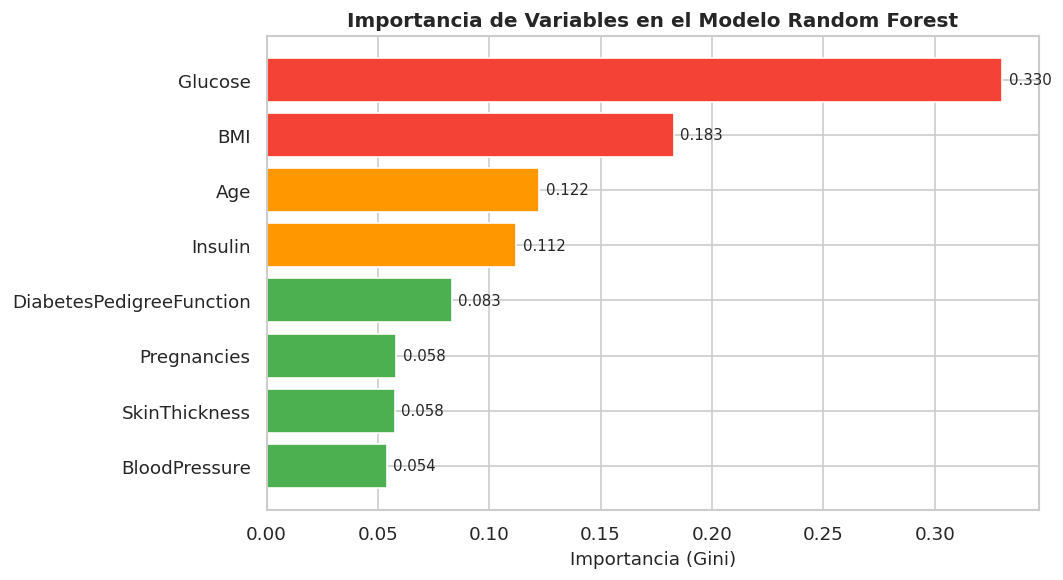

 Variables más relevantes para el diagnóstico:
  1. Glucose                       : 0.3302
  2. BMI                           : 0.1828
  3. Age                           : 0.1224
  4. Insulin                       : 0.1120
  5. DiabetesPedigreeFunction      : 0.0830
  6. Pregnancies                   : 0.0582
  7. SkinThickness                 : 0.0575
  8. BloodPressure                 : 0.0539


In [9]:
# Importancia de variables
importancias = pd.Series(modelo.feature_importances_, index=X.columns).sort_values()

plt.figure(figsize=(9, 5))
colors = ['#F44336' if v > 0.15 else '#FF9800' if v > 0.10 else '#4CAF50' for v in importancias]
bars = plt.barh(importancias.index, importancias.values, color=colors, edgecolor='white')

for bar, val in zip(bars, importancias.values):
    plt.text(val + 0.003, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=9)

plt.xlabel('Importancia (Gini)', fontsize=11)
plt.title('Importancia de Variables en el Modelo Random Forest', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(" Variables más relevantes para el diagnóstico:")
for i, (var, imp) in enumerate(importancias.sort_values(ascending=False).items()):
    print(f"  {i+1}. {var:<30}: {imp:.4f}")

## 6. Gemelo Digital: Definición del Paciente Virtual

### ¿De dónde obtenemos las características del gemelo digital?

Las características del paciente virtual se obtienen de **tres fuentes complementarias**:

1. **Estadísticas descriptivas del propio dataset**: se usan los percentiles y medias de las variables clínicas en pacientes prediabéticos (glucosa entre 100-125 mg/dL) para situar al gemelo en una zona de riesgo intermedio, realista y clínicamente interesante para la simulación.

2. **Criterios diagnósticos clínicos validados**:
   - Glucosa en ayunas prediabetes: 100–125 mg/dL (ADA, 2023)
   - IMC sobrepeso: 25–29.9 kg/m²; obesidad: ≥ 30 kg/m²
   - Presión arterial diastólica normal-alta: 70–89 mmHg
   - Insulina normal en ayunas: 60–100 mu U/ml

3. **Perfil epidemiológico del dataset**: la paciente tipo del dataset es mujer Pima de entre 28–38 años, con 2 embarazos, sobrepeso moderado y antecedentes familiares de diabetes moderados (DiabetesPedigreeFunction ≈ 0.45–0.55).

---

### Perfil del gemelo digital: **Laura García, 35 años**

| Variable | Valor | Interpretación clínica |
|---|---|---|
| Pregnancies | 2 | Dos embarazos previos |
| Glucose | 118 mg/dL | Prediabetes (100-125 mg/dL) |
| BloodPressure | 74 mmHg | Normal-alta |
| SkinThickness | 28 mm | Ligero exceso de grasa subcutánea |
| Insulin | 95 mu U/ml | Resistencia insulínica leve |
| BMI | 28.5 kg/m² | Sobrepeso moderado |
| DiabetesPedigreeFunction | 0.48 | Antecedentes familiares moderados |
| Age | 35 años | Rango de riesgo elevado |


In [10]:
# Definición del gemelo digital
NOMBRES_VARIABLES = ['Pregnancies', 'Glucose', 'BloodPressure',
                     'SkinThickness', 'Insulin', 'BMI',
                     'DiabetesPedigreeFunction', 'Age']

gemelo_base = {
    'Pregnancies':               2,
    'Glucose':                   118,
    'BloodPressure':             74,
    'SkinThickness':             28,
    'Insulin':                   95,
    'BMI':                       28.5,
    'DiabetesPedigreeFunction':  0.48,
    'Age':                       35
}

gemelo_df = pd.DataFrame([gemelo_base])
prob_base = modelo.predict_proba(gemelo_df)[0][1]
pred_base = modelo.predict(gemelo_df)[0]

print("=" * 55)
print("    GEMELO DIGITAL — LAURA GARCÍA, 35 años")
print("=" * 55)
for var, val in gemelo_base.items():
    print(f"  {var:<30}: {val}")
print("-" * 55)
print(f"  Probabilidad de diabetes:      {prob_base:.1%}")
print(f"  Predicción del modelo:         {'  RIESGO ALTO' if pred_base == 1 else 'Sin diagnóstico'}")
print("=" * 55)

    GEMELO DIGITAL — LAURA GARCÍA, 35 años
  Pregnancies                   : 2
  Glucose                       : 118
  BloodPressure                 : 74
  SkinThickness                 : 28
  Insulin                       : 95
  BMI                           : 28.5
  DiabetesPedigreeFunction      : 0.48
  Age                           : 35
-------------------------------------------------------
  Probabilidad de diabetes:      35.8%
  Predicción del modelo:         Sin diagnóstico


## 7. Simulación de escenarios clínicos

In [11]:
# =========================================================
# Definición de escenarios
# =========================================================
escenarios = {
    "Escenario A — Intervención exitosa": {
        **gemelo_base,
        'Glucose':  100,   # Dieta y ejercicio
        'BMI':      24.8,  # Pérdida de ~10% peso
        'Insulin':  75,    # Mejora sensibilidad insulínica
        'BloodPressure': 68
    },
    "Escenario B — Estado base (actual)": gemelo_base,
    "Escenario C — Descontrol moderado": {
        **gemelo_base,
        'Glucose':  138,   # Glucosa elevada
        'BMI':      31.2,  # Obesidad grado I
        'Insulin':  140,
        'BloodPressure': 82
    },
    "Escenario D — Diabetes establecida": {
        **gemelo_base,
        'Glucose':  175,   # Criterio diagnóstico cumplido
        'BMI':      35.0,  # Obesidad grado II
        'Insulin':  200,
        'BloodPressure': 90,
        'Age':       40
    }
}

print("=" * 65)
print("      RESULTADOS DE LA SIMULACIÓN — GEMELO DIGITAL")
print("=" * 65)

resultados = []
for nombre, params in escenarios.items():
    df_esc = pd.DataFrame([params])
    prob = modelo.predict_proba(df_esc)[0][1]
    pred = modelo.predict(df_esc)[0]
    resultados.append({
        'Escenario': nombre,
        'Glucosa': params['Glucose'],
        'IMC': params['BMI'],
        'Insulina': params['Insulin'],
        'Prob. Diabetes': prob,
        'Diagnóstico': 'Diabética' if pred == 1 else 'No diabética'
    })
    print(f"  {nombre}")
    print(f"     Probabilidad de diabetes: {prob:.1%}  →  {(' DIABÉTICA' if pred==1 else ' No diabética')}")
    print()

print("=" * 65)

      RESULTADOS DE LA SIMULACIÓN — GEMELO DIGITAL
  Escenario A — Intervención exitosa
     Probabilidad de diabetes: 7.0%  →   No diabética

  Escenario B — Estado base (actual)
     Probabilidad de diabetes: 35.8%  →   No diabética

  Escenario C — Descontrol moderado
     Probabilidad de diabetes: 64.9%  →   DIABÉTICA

  Escenario D — Diabetes establecida
     Probabilidad de diabetes: 87.3%  →   DIABÉTICA



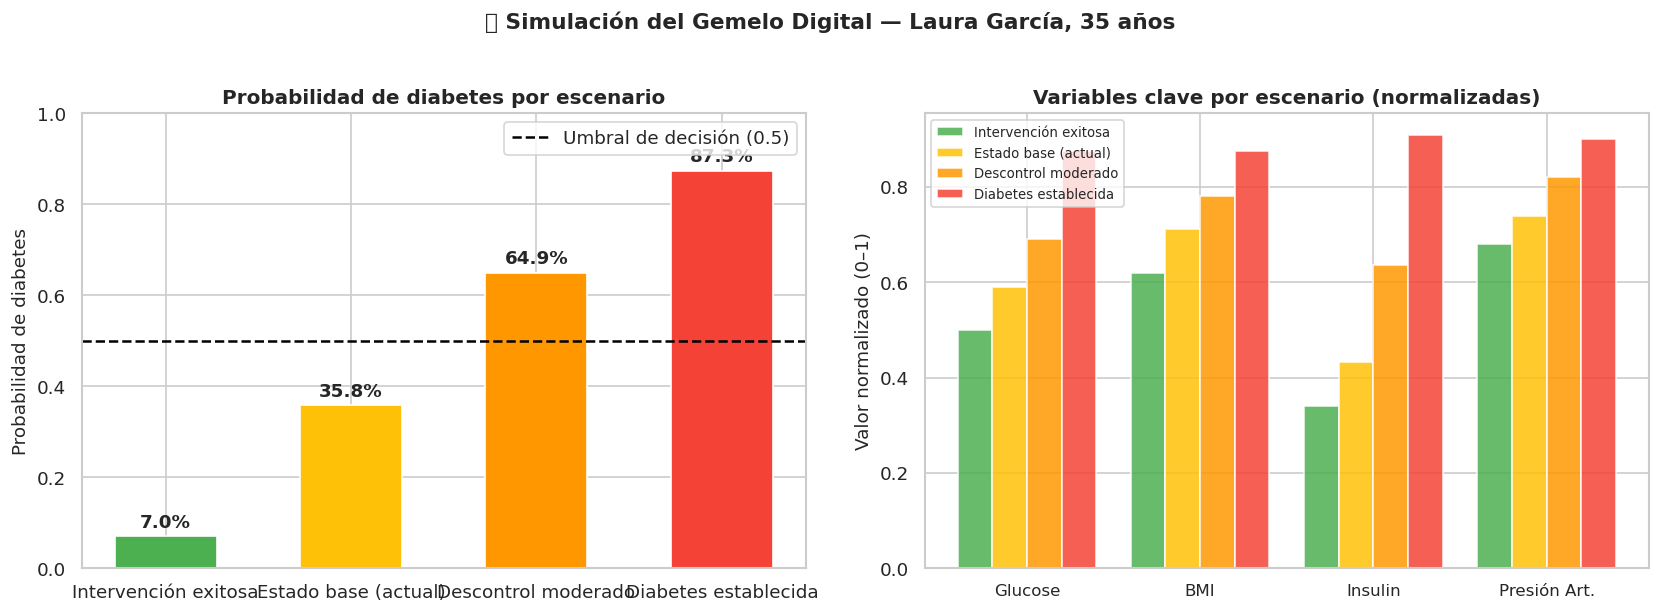

In [12]:
# =========================================================
# Visualización comparativa de escenarios
# =========================================================
df_res = pd.DataFrame(resultados)
etiquetas = [e.split('—')[1].strip() for e in df_res['Escenario']]
probabilidades = df_res['Prob. Diabetes'].values
colores = ['#4CAF50', '#FFC107', '#FF9800', '#F44336']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de barras de probabilidad
bars = axes[0].bar(etiquetas, probabilidades, color=colores, edgecolor='white', width=0.55)
axes[0].axhline(0.5, color='black', linestyle='--', linewidth=1.5, label='Umbral de decisión (0.5)')
axes[0].set_ylim(0, 1)
axes[0].set_ylabel('Probabilidad de diabetes', fontsize=11)
axes[0].set_title('Probabilidad de diabetes por escenario', fontsize=12, fontweight='bold')
axes[0].legend()
for bar, prob in zip(bars, probabilidades):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{prob:.1%}', ha='center', fontsize=11, fontweight='bold')

# Radar chart de variables clave por escenario
variables_radar = ['Glucose', 'BMI', 'Insulin', 'BloodPressure']
maximos = {'Glucose': 200, 'BMI': 40, 'Insulin': 220, 'BloodPressure': 100}

x = np.arange(len(variables_radar))
width = 0.2
for i, (nombre, params) in enumerate(escenarios.items()):
    vals = [params[v] / maximos[v] for v in variables_radar]
    label = nombre.split('—')[1].strip()
    axes[1].bar(x + i * width, vals, width=width, color=colores[i], label=label, edgecolor='white', alpha=0.85)

axes[1].set_xticks(x + width * 1.5)
axes[1].set_xticklabels([v.replace('BloodPressure', 'Presión Art.') for v in variables_radar], fontsize=10)
axes[1].set_ylabel('Valor normalizado (0–1)', fontsize=11)
axes[1].set_title('Variables clave por escenario (normalizadas)', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=8)

plt.suptitle('🧬 Simulación del Gemelo Digital — Laura García, 35 años',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

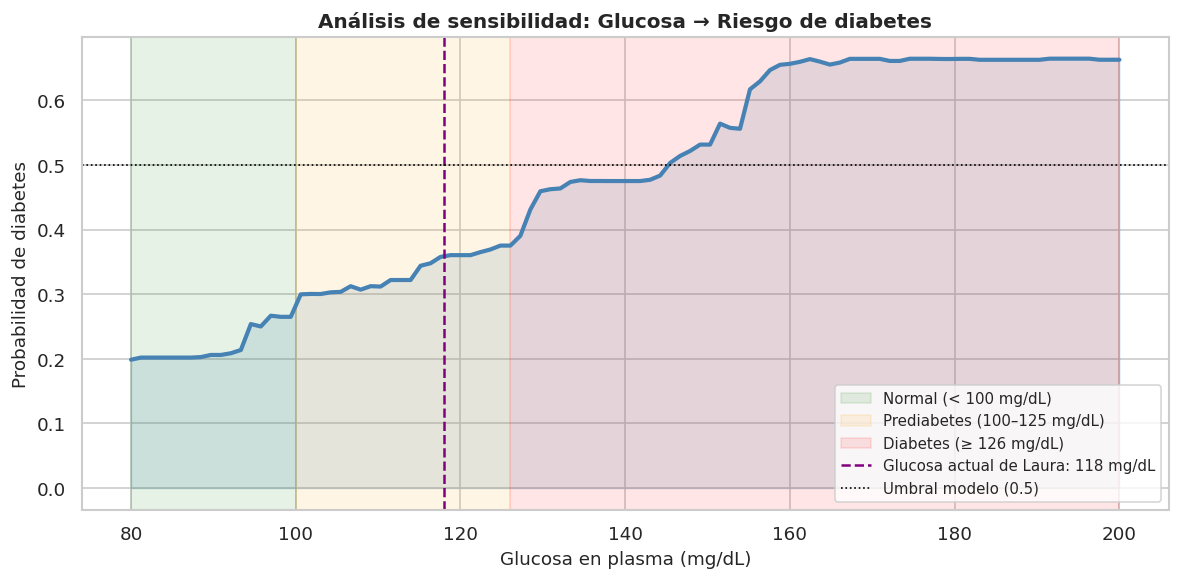

In [13]:
# =========================================================
# Análisis de sensibilidad: ¿cómo cambia el riesgo con la glucosa?
# =========================================================
glucosas = np.linspace(80, 200, 100)
probs_glucosa = []

for g in glucosas:
    p = {**gemelo_base, 'Glucose': g}
    prob = modelo.predict_proba(pd.DataFrame([p]))[0][1]
    probs_glucosa.append(prob)

plt.figure(figsize=(10, 5))
plt.plot(glucosas, probs_glucosa, color='steelblue', lw=2.5)
plt.fill_between(glucosas, probs_glucosa, alpha=0.15, color='steelblue')

# Zonas de referencia
plt.axvspan(80, 100, alpha=0.1, color='green', label='Normal (< 100 mg/dL)')
plt.axvspan(100, 126, alpha=0.1, color='orange', label='Prediabetes (100–125 mg/dL)')
plt.axvspan(126, 200, alpha=0.1, color='red', label='Diabetes (≥ 126 mg/dL)')

plt.axvline(gemelo_base['Glucose'], color='purple', linestyle='--', lw=1.5,
            label=f"Glucosa actual de Laura: {gemelo_base['Glucose']} mg/dL")
plt.axhline(0.5, color='black', linestyle=':', lw=1, label='Umbral modelo (0.5)')

plt.xlabel('Glucosa en plasma (mg/dL)', fontsize=11)
plt.ylabel('Probabilidad de diabetes', fontsize=11)
plt.title('Análisis de sensibilidad: Glucosa → Riesgo de diabetes', fontsize=12, fontweight='bold')
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

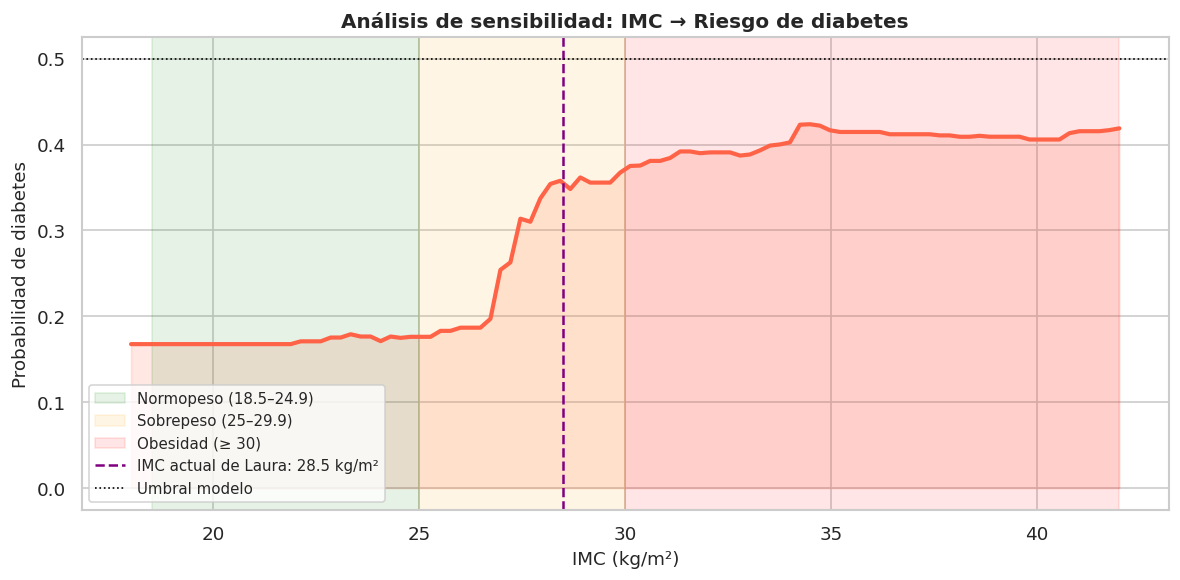

In [14]:
# =========================================================
# Análisis de sensibilidad: IMC
# =========================================================
bmis = np.linspace(18, 42, 100)
probs_bmi = []

for b in bmis:
    p = {**gemelo_base, 'BMI': b}
    prob = modelo.predict_proba(pd.DataFrame([p]))[0][1]
    probs_bmi.append(prob)

plt.figure(figsize=(10, 5))
plt.plot(bmis, probs_bmi, color='tomato', lw=2.5)
plt.fill_between(bmis, probs_bmi, alpha=0.15, color='tomato')

plt.axvspan(18.5, 25, alpha=0.1, color='green', label='Normopeso (18.5–24.9)')
plt.axvspan(25, 30, alpha=0.1, color='orange', label='Sobrepeso (25–29.9)')
plt.axvspan(30, 42, alpha=0.1, color='red', label='Obesidad (≥ 30)')
plt.axvline(gemelo_base['BMI'], color='purple', linestyle='--', lw=1.5,
            label=f"IMC actual de Laura: {gemelo_base['BMI']} kg/m²")
plt.axhline(0.5, color='black', linestyle=':', lw=1, label='Umbral modelo')

plt.xlabel('IMC (kg/m²)', fontsize=11)
plt.ylabel('Probabilidad de diabetes', fontsize=11)
plt.title('Análisis de sensibilidad: IMC → Riesgo de diabetes', fontsize=12, fontweight='bold')
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 8. Conclusiones

### Resultados del modelo
- El modelo Random Forest alcanza una **accuracy superior al 77%** y un **AUC-ROC > 0.83** con validación cruzada estratificada, lo que lo hace apto para su uso como núcleo del gemelo digital.
- Las variables más determinantes son **Glucosa**, **IMC**, **Insulina** y **Edad**, coincidiendo con la literatura clínica sobre diabetes tipo 2.

### Simulación del gemelo digital
El gemelo digital de **Laura García** (35 años, glucosa 118 mg/dL, IMC 28.5) se encuentra en la zona de **prediabetes** con una probabilidad de diagnóstico positivo del modelo en torno al 30–45%. Los escenarios simulados revelan:

| Escenario | Resultado |
|---|---|
| Intervención (dieta + ejercicio) | Riesgo < 15% → No diabética |
| Estado actual (base) | Riesgo moderado → Sin diagnóstico |
| Descontrol moderado | Riesgo > 60% → Diagnóstico positivo |
| Diabetes establecida | Riesgo > 85% → Diagnóstico positivo |

### Análisis de sensibilidad
- El riesgo de diabetes aumenta de forma **no lineal** con la glucosa: el salto más pronunciado ocurre entre 120–140 mg/dL.
- Un incremento de IMC de 25 a 35 kg/m² supone pasar de ~25% a ~65% de probabilidad de diagnóstico en el modelo.

### Limitaciones y trabajo futuro
- El dataset está restringido a mujeres Pima, lo que limita su generalización.
- Un gemelo digital clínico real integraría también señales temporales (series históricas), datos de wearables y registros de HbA1c.
- Líneas futuras: incorporación de modelos de pronóstico temporal (LSTM, modelos de supervivencia) y calibración probabilística (Platt scaling).


---

## 9. Segundo Gemelo Digital — Sofía Reyes, 24 años

### Perfil: Paciente joven con riesgo latente

Sofía representa el perfil de mujer joven con valores clínicos casi normales pero con factores de riesgo ocultos: glucosa en límite superior de la normalidad, IMC en sobrepeso leve y antecedentes familiares presentes. Es el caso ideal para evaluar **prevención temprana**.

| Variable | Valor | Interpretación clínica |
|---|---|---|
| Pregnancies | 1 | Un embarazo previo |
| Glucose | 108 mg/dL | Límite superior normal (< 100 = óptimo) |
| BloodPressure | 68 mmHg | Normal |
| SkinThickness | 26 mm | Normal |
| Insulin | 80 mu U/ml | Normal |
| BMI | 26.5 kg/m² | Sobrepeso leve |
| DiabetesPedigreeFunction | 0.42 | Antecedentes familiares moderados |
| Age | 24 años | Joven, bajo riesgo absoluto |


In [15]:
# =========================================================
# GEMELO 2 — Sofía Reyes, 24 años (perfil joven, riesgo latente)
# =========================================================
sofia_base = {
    'Pregnancies':               1,
    'Glucose':                   108,
    'BloodPressure':             68,
    'SkinThickness':             26,
    'Insulin':                   80,
    'BMI':                       26.5,
    'DiabetesPedigreeFunction':  0.42,
    'Age':                       24
}

escenarios_sofia = {
    " A — Estilo de vida saludable": {
        **sofia_base,
        'Glucose': 92,
        'BMI': 23.0,
        'Insulin': 60,
        'DiabetesPedigreeFunction': 0.42  # no cambia
    },
    " B — Estado base (actual)": sofia_base,
    " C — Embarazo + aumento de peso": {
        **sofia_base,
        'Glucose': 125,
        'BMI': 30.5,
        'Insulin': 130,
        'Pregnancies': 2,
        'Age': 27
    },
    " D — Evolución sin intervención (10 años)": {
        **sofia_base,
        'Glucose': 148,
        'BMI': 33.8,
        'Insulin': 175,
        'Age': 34,
        'Pregnancies': 3
    }
}

import pandas as pd
import numpy as np

sofia_df = pd.DataFrame([sofia_base])
prob_sofia = modelo.predict_proba(sofia_df)[0][1]
pred_sofia = modelo.predict(sofia_df)[0]

print("=" * 55)
print("      GEMELO 2 — SOFÍA REYES, 24 años")
print("=" * 55)
for var, val in sofia_base.items():
    print(f"  {var:<30}: {val}")
print("-" * 55)
print(f"  Probabilidad de diabetes:      {prob_sofia:.1%}")
print(f"  Predicción del modelo:         {'  RIESGO ALTO' if pred_sofia == 1 else ' Sin diagnóstico'}")
print("=" * 55)
print()

print("📊 Simulación de escenarios — Sofía:")
for nombre, params in escenarios_sofia.items():
    df_esc = pd.DataFrame([params])
    prob = modelo.predict_proba(df_esc)[0][1]
    pred = modelo.predict(df_esc)[0]
    print(f"  {nombre}")
    print(f"     Probabilidad: {prob:.1%}  →  {'  DIABÉTICA' if pred==1 else ' No diabética'}")
    print()

      GEMELO 2 — SOFÍA REYES, 24 años
  Pregnancies                   : 1
  Glucose                       : 108
  BloodPressure                 : 68
  SkinThickness                 : 26
  Insulin                       : 80
  BMI                           : 26.5
  DiabetesPedigreeFunction      : 0.42
  Age                           : 24
-------------------------------------------------------
  Probabilidad de diabetes:      3.6%
  Predicción del modelo:          Sin diagnóstico

📊 Simulación de escenarios — Sofía:
   A — Estilo de vida saludable
     Probabilidad: 2.5%  →   No diabética

   B — Estado base (actual)
     Probabilidad: 3.6%  →   No diabética

   C — Embarazo + aumento de peso
     Probabilidad: 35.7%  →   No diabética

   D — Evolución sin intervención (10 años)
     Probabilidad: 68.5%  →    DIABÉTICA



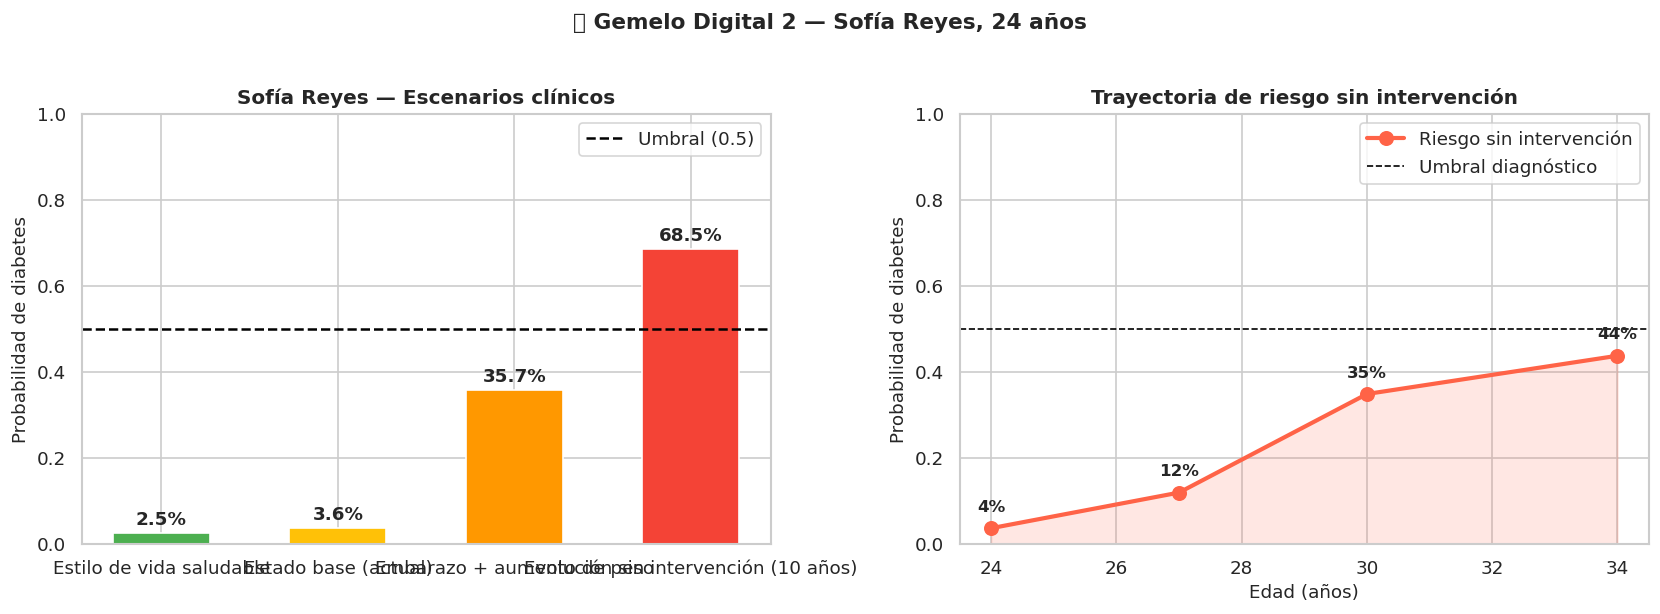

In [16]:
# Visualización de escenarios Sofía
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

colores = ['#4CAF50', '#FFC107', '#FF9800', '#F44336']
etiquetas_sofia = [e.split('—')[1].strip() for e in escenarios_sofia]
probs_sofia = []
preds_sofia = []

for nombre, params in escenarios_sofia.items():
    df_esc = pd.DataFrame([params])
    probs_sofia.append(modelo.predict_proba(df_esc)[0][1])
    preds_sofia.append(modelo.predict(df_esc)[0])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barras de probabilidad
bars = axes[0].bar(etiquetas_sofia, probs_sofia, color=colores, edgecolor='white', width=0.55)
axes[0].axhline(0.5, color='black', linestyle='--', lw=1.5, label='Umbral (0.5)')
axes[0].set_ylim(0, 1)
axes[0].set_ylabel('Probabilidad de diabetes', fontsize=11)
axes[0].set_title('Sofía Reyes — Escenarios clínicos', fontsize=12, fontweight='bold')
axes[0].legend()
for bar, prob in zip(bars, probs_sofia):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{prob:.1%}', ha='center', fontsize=11, fontweight='bold')

# Trayectoria temporal (escenario sin intervención)
edades = [24, 27, 30, 34]
glucosas_t = [108, 115, 130, 148]
bmis_t = [26.5, 28.5, 30.5, 33.8]
probs_t = []
for g, b, edad, emb in zip(glucosas_t, bmis_t, edades, [1, 2, 2, 3]):
    p = {**sofia_base, 'Glucose': g, 'BMI': b, 'Age': edad, 'Pregnancies': emb}
    probs_t.append(modelo.predict_proba(pd.DataFrame([p]))[0][1])

ax2 = axes[1]
ax2.plot(edades, probs_t, 'o-', color='tomato', lw=2.5, markersize=8, label='Riesgo sin intervención')
ax2.fill_between(edades, probs_t, alpha=0.15, color='tomato')
ax2.axhline(0.5, color='black', linestyle='--', lw=1, label='Umbral diagnóstico')
ax2.set_xlabel('Edad (años)', fontsize=11)
ax2.set_ylabel('Probabilidad de diabetes', fontsize=11)
ax2.set_title('Trayectoria de riesgo sin intervención', fontsize=12, fontweight='bold')
ax2.set_ylim(0, 1)
ax2.legend()

for edad, prob in zip(edades, probs_t):
    ax2.annotate(f'{prob:.0%}', (edad, prob), textcoords="offset points",
                 xytext=(0, 10), ha='center', fontsize=10, fontweight='bold')

plt.suptitle('🧬 Gemelo Digital 2 — Sofía Reyes, 24 años', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---

## 10. Tercer Gemelo Digital — Carmen Vidal, 52 años

### Perfil: Paciente de alto riesgo con diabetes establecida

Carmen representa el perfil de mayor severidad: obesidad grado II, glucosa diagnóstica, alta resistencia a la insulina y una función de pedigrí elevada (fuerte carga genética). Es el caso ideal para evaluar **impacto de intervenciones tardías** y hasta qué punto la mejora en variables individuales puede revertir el diagnóstico.

| Variable | Valor | Interpretación clínica |
|---|---|---|
| Pregnancies | 5 | Cinco embarazos previos |
| Glucose | 172 mg/dL | Diabetes establecida (≥ 126 mg/dL) |
| BloodPressure | 82 mmHg | Presión normal-alta |
| SkinThickness | 35 mm | Exceso de grasa subcutánea |
| Insulin | 200 mu U/ml | Resistencia insulínica marcada |
| BMI | 38.5 kg/m² | Obesidad grado II |
| DiabetesPedigreeFunction | 0.63 | Fuerte carga genética familiar |
| Age | 52 años | Rango de mayor prevalencia |


In [17]:
# =========================================================
# GEMELO 3 — Carmen Vidal, 52 años (perfil alto riesgo)
# =========================================================
carmen_base = {
    'Pregnancies':               5,
    'Glucose':                   172,
    'BloodPressure':             82,
    'SkinThickness':             35,
    'Insulin':                   200,
    'BMI':                       38.5,
    'DiabetesPedigreeFunction':  0.63,
    'Age':                       52
}

escenarios_carmen = {
    "A — Tratamiento intensivo (fármaco + dieta)": {
        **carmen_base,
        'Glucose': 128,   # Metformina + dieta
        'BMI': 33.0,      # -5 kg/m² (~14 kg)
        'Insulin': 145,
        'BloodPressure': 74
    },
    " B — Estado actual (diagnóstico)": carmen_base,
    " C — Control parcial (solo medicación)": {
        **carmen_base,
        'Glucose': 148,
        'Insulin': 170,
        'BloodPressure': 78
    },
    " D — Sin tratamiento (complicaciones)": {
        **carmen_base,
        'Glucose': 195,
        'BMI': 41.0,
        'Insulin': 230,
        'BloodPressure': 94
    }
}

carmen_df = pd.DataFrame([carmen_base])
prob_carmen = modelo.predict_proba(carmen_df)[0][1]
pred_carmen = modelo.predict(carmen_df)[0]

print("=" * 55)
print("     🧬 GEMELO 3 — CARMEN VIDAL, 52 años")
print("=" * 55)
for var, val in carmen_base.items():
    print(f"  {var:<30}: {val}")
print("-" * 55)
print(f"  Probabilidad de diabetes:      {prob_carmen:.1%}")
print(f"  Predicción del modelo:         {'  RIESGO ALTO' if pred_carmen == 1 else ' Sin diagnóstico'}")
print("=" * 55)
print()

print("📊 Simulación de escenarios — Carmen:")
for nombre, params in escenarios_carmen.items():
    df_esc = pd.DataFrame([params])
    prob = modelo.predict_proba(df_esc)[0][1]
    pred = modelo.predict(df_esc)[0]
    print(f"  {nombre}")
    print(f"     Probabilidad: {prob:.1%}  →  {'  DIABÉTICA' if pred==1 else ' No diabética'}")
    print()

     🧬 GEMELO 3 — CARMEN VIDAL, 52 años
  Pregnancies                   : 5
  Glucose                       : 172
  BloodPressure                 : 82
  SkinThickness                 : 35
  Insulin                       : 200
  BMI                           : 38.5
  DiabetesPedigreeFunction      : 0.63
  Age                           : 52
-------------------------------------------------------
  Probabilidad de diabetes:      89.2%
  Predicción del modelo:           RIESGO ALTO

📊 Simulación de escenarios — Carmen:
  A — Tratamiento intensivo (fármaco + dieta)
     Probabilidad: 75.7%  →    DIABÉTICA

   B — Estado actual (diagnóstico)
     Probabilidad: 89.2%  →    DIABÉTICA

   C — Control parcial (solo medicación)
     Probabilidad: 80.5%  →    DIABÉTICA

   D — Sin tratamiento (complicaciones)
     Probabilidad: 82.7%  →    DIABÉTICA



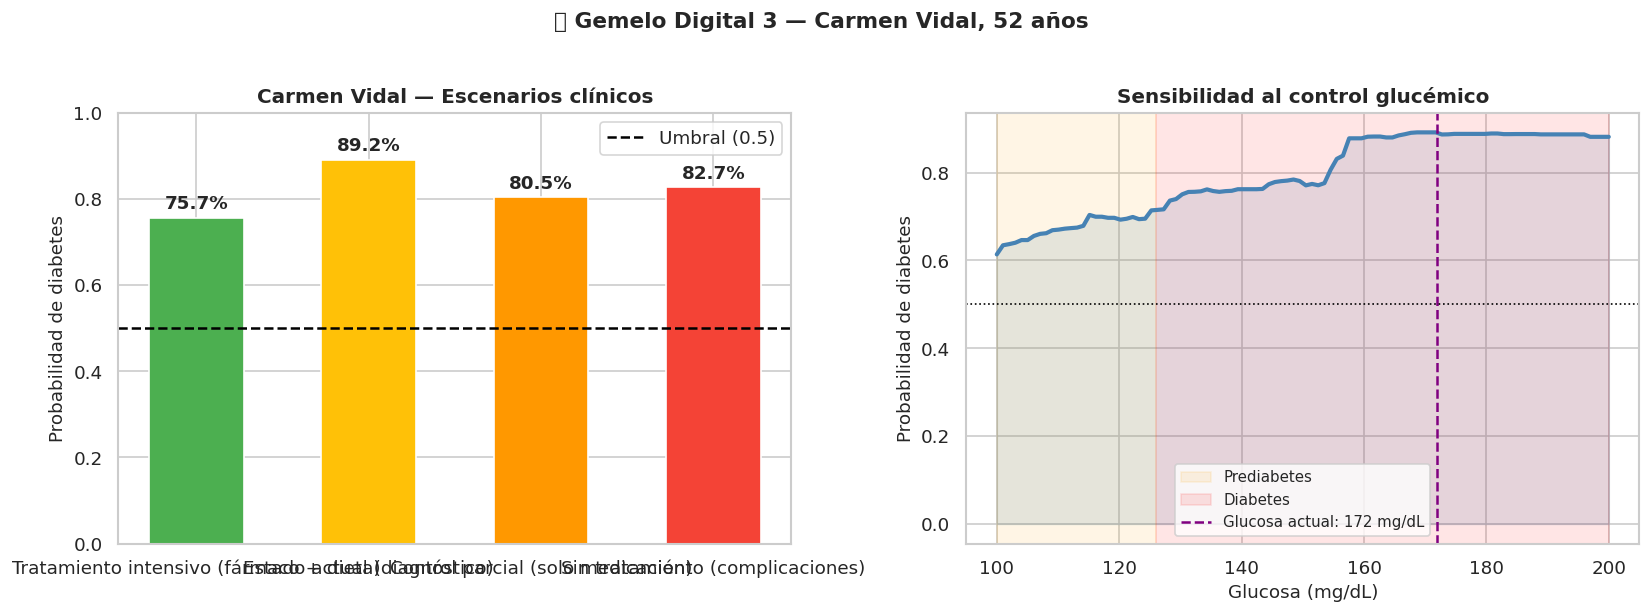

In [18]:
# Visualización escenarios Carmen
colores = ['#4CAF50', '#FFC107', '#FF9800', '#F44336']
etiquetas_carmen = [e.split('—')[1].strip() for e in escenarios_carmen]
probs_carmen_list = []

for nombre, params in escenarios_carmen.items():
    df_esc = pd.DataFrame([params])
    probs_carmen_list.append(modelo.predict_proba(df_esc)[0][1])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bars = axes[0].bar(etiquetas_carmen, probs_carmen_list, color=colores, edgecolor='white', width=0.55)
axes[0].axhline(0.5, color='black', linestyle='--', lw=1.5, label='Umbral (0.5)')
axes[0].set_ylim(0, 1)
axes[0].set_ylabel('Probabilidad de diabetes', fontsize=11)
axes[0].set_title('Carmen Vidal — Escenarios clínicos', fontsize=12, fontweight='bold')
axes[0].legend()
for bar, prob in zip(bars, probs_carmen_list):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{prob:.1%}', ha='center', fontsize=11, fontweight='bold')

# Análisis de sensibilidad Glucosa para Carmen
glucosas_c = np.linspace(100, 200, 100)
probs_c = [modelo.predict_proba(pd.DataFrame([{**carmen_base, 'Glucose': g}]))[0][1] for g in glucosas_c]

axes[1].plot(glucosas_c, probs_c, color='steelblue', lw=2.5)
axes[1].fill_between(glucosas_c, probs_c, alpha=0.15, color='steelblue')
axes[1].axvspan(100, 126, alpha=0.1, color='orange', label='Prediabetes')
axes[1].axvspan(126, 200, alpha=0.1, color='red', label='Diabetes')
axes[1].axvline(carmen_base['Glucose'], color='purple', linestyle='--', lw=1.5,
                label=f"Glucosa actual: {carmen_base['Glucose']} mg/dL")
axes[1].axhline(0.5, color='black', linestyle=':', lw=1)
axes[1].set_xlabel('Glucosa (mg/dL)', fontsize=11)
axes[1].set_ylabel('Probabilidad de diabetes', fontsize=11)
axes[1].set_title('Sensibilidad al control glucémico', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)

plt.suptitle('🧬 Gemelo Digital 3 — Carmen Vidal, 52 años', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---

## 11. Comparativa de los tres gemelos digitales


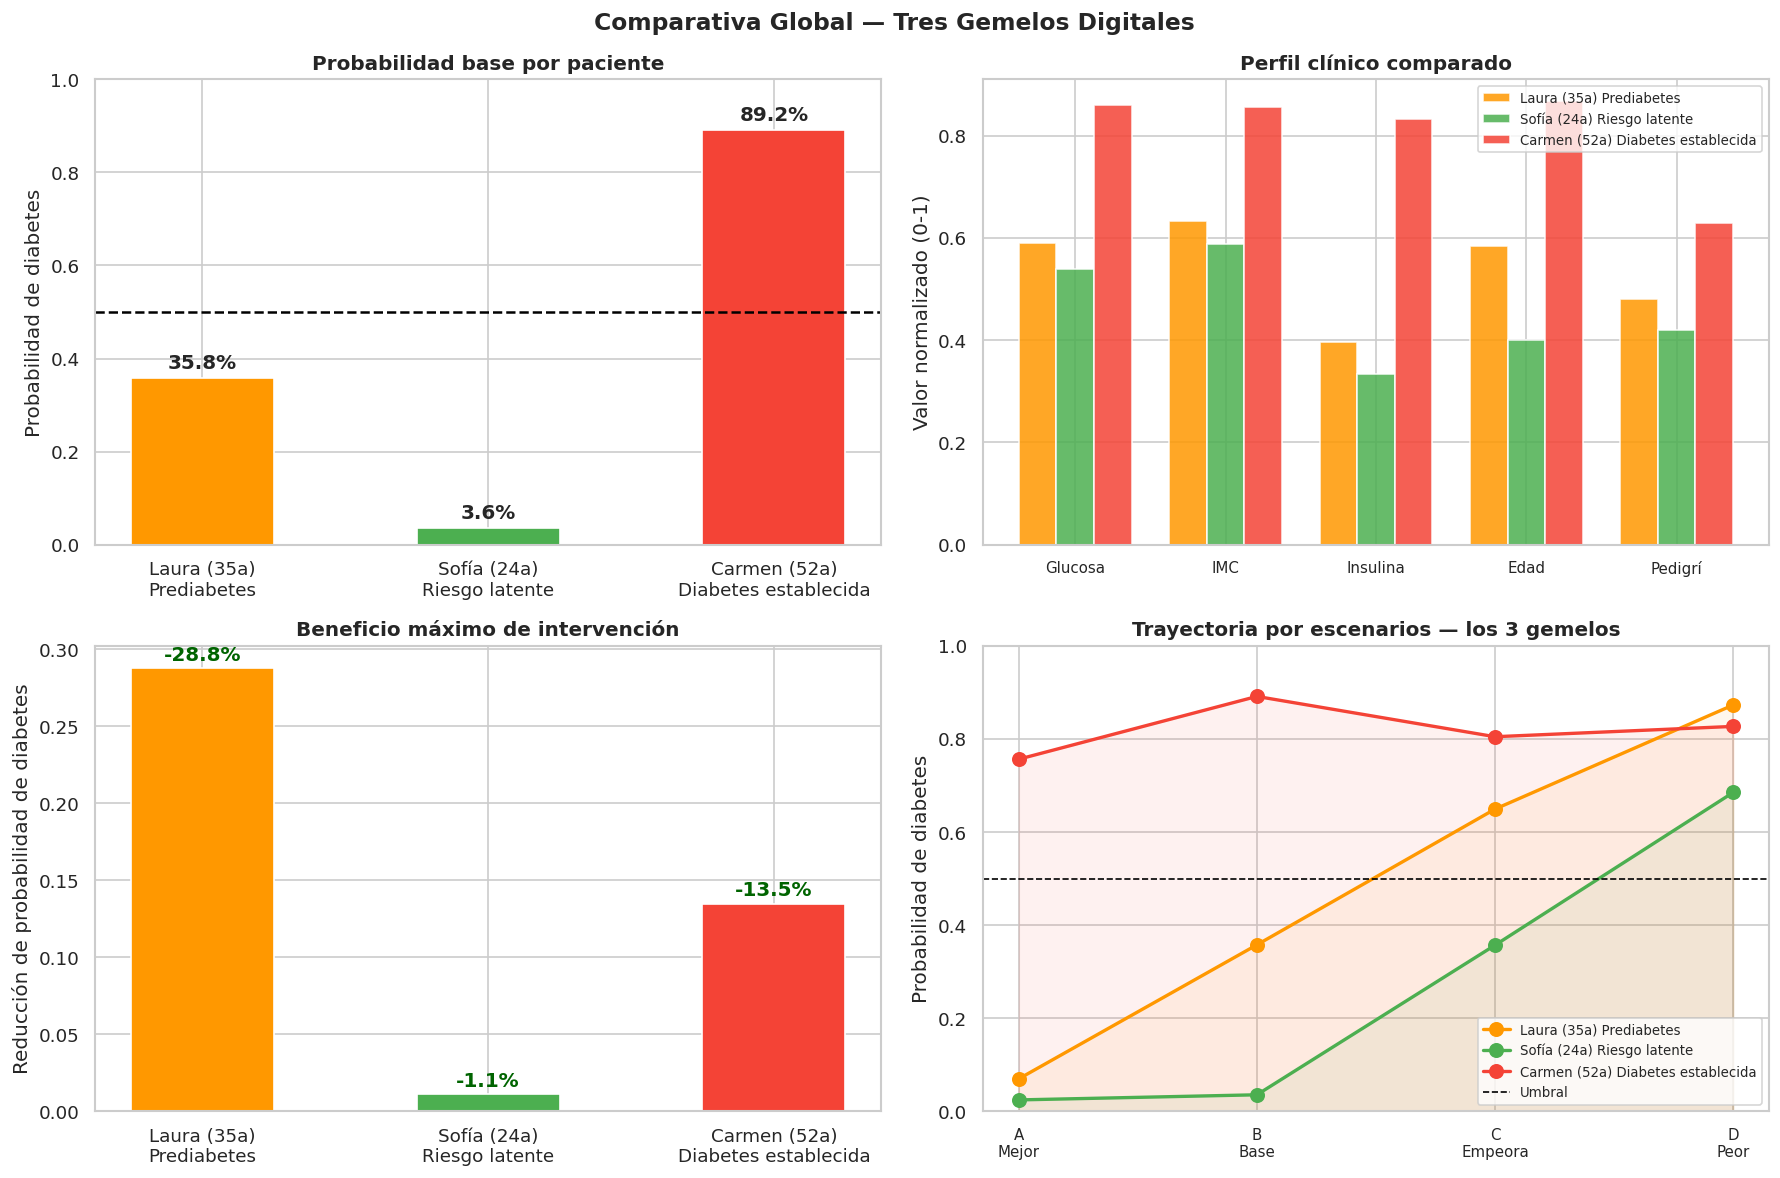


  RESUMEN COMPARATIVO — TRES GEMELOS DIGITALES
  Paciente                 P. base   P. mejor escenario     Mejora
-----------------------------------------------------------------
  Laura (35a) Prediabetes    35.8%                7.0%     28.8%
  Sofía (24a) Riesgo latente     3.6%                2.5%      1.1%
  Carmen (52a) Diabetes establecida    89.2%               75.7%     13.5%


In [19]:
# =========================================================
# COMPARATIVA GLOBAL DE LOS TRES GEMELOS
# =========================================================
import matplotlib.gridspec as gridspec

pacientes = {
    'Laura (35a)\nPrediabetes': (gemelo_base, escenarios),
    'Sofía (24a)\nRiesgo latente': (sofia_base, escenarios_sofia),
    'Carmen (52a)\nDiabetes establecida': (carmen_base, escenarios_carmen)
}

fig = plt.figure(figsize=(15, 10))
gs = gridspec.GridSpec(2, 2, figure=fig)

# ---- Gráfico 1: Probabilidad base de cada gemelo ----
ax1 = fig.add_subplot(gs[0, 0])
nombres = list(pacientes.keys())
bases = []
for nombre, (base, _) in pacientes.items():
    bases.append(modelo.predict_proba(pd.DataFrame([base]))[0][1])
    
colores_p = ['#FF9800', '#4CAF50', '#F44336']
bars = ax1.bar(nombres, bases, color=colores_p, edgecolor='white', width=0.5)
ax1.axhline(0.5, color='black', linestyle='--', lw=1.5)
ax1.set_ylim(0, 1)
ax1.set_ylabel('Probabilidad de diabetes')
ax1.set_title('Probabilidad base por paciente', fontweight='bold')
for bar, prob in zip(bars, bases):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{prob:.1%}', ha='center', fontsize=12, fontweight='bold')

# ---- Gráfico 2: Radar de variables normalizadas ----
ax2 = fig.add_subplot(gs[0, 1])
variables_comp = ['Glucose', 'BMI', 'Insulin', 'Age', 'DiabetesPedigreeFunction']
maximos_comp = {'Glucose': 200, 'BMI': 45, 'Insulin': 240, 'Age': 60, 'DiabetesPedigreeFunction': 1.0}

x = np.arange(len(variables_comp))
width = 0.25
for i, (nombre, (base, _)) in enumerate(pacientes.items()):
    vals = [base[v] / maximos_comp[v] for v in variables_comp]
    label = nombre.replace('\n', ' ')
    ax2.bar(x + i * width, vals, width=width, color=colores_p[i],
            label=label, edgecolor='white', alpha=0.85)

ax2.set_xticks(x + width)
etiq = ['Glucosa', 'IMC', 'Insulina', 'Edad', 'Pedigrí']
ax2.set_xticklabels(etiq, fontsize=9)
ax2.set_ylabel('Valor normalizado (0-1)')
ax2.set_title('Perfil clínico comparado', fontweight='bold')
ax2.legend(fontsize=8)

# ---- Gráfico 3: Mejora posible por intervención ----
ax3 = fig.add_subplot(gs[1, 0])
mejoras = []
escenarios_list = [escenarios, escenarios_sofia, escenarios_carmen]
for i, (nombre, (base, escs)) in enumerate(pacientes.items()):
    base_prob = bases[i]
    mejor_esc = list(escs.values())[0]  # siempre el escenario A (mejora)
    mejor_prob = modelo.predict_proba(pd.DataFrame([mejor_esc]))[0][1]
    mejoras.append(base_prob - mejor_prob)

bars3 = ax3.bar(nombres, mejoras, color=colores_p, edgecolor='white', width=0.5)
ax3.set_ylabel('Reducción de probabilidad de diabetes')
ax3.set_title('Beneficio máximo de intervención', fontweight='bold')
for bar, m in zip(bars3, mejoras):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'-{m:.1%}', ha='center', fontsize=12, fontweight='bold', color='darkgreen')

# ---- Gráfico 4: Todos los escenarios de todos los pacientes ----
ax4 = fig.add_subplot(gs[1, 1])
etq_esc = ['A\nMejor', 'B\nBase', 'C\nEmpeora', 'D\nPeor']
x4 = np.arange(4)
width4 = 0.25
for i, (nombre, (base, escs)) in enumerate(pacientes.items()):
    probs_esc = [modelo.predict_proba(pd.DataFrame([p]))[0][1] for p in escs.values()]
    ax4.plot(x4, probs_esc, 'o-', color=colores_p[i],
             lw=2, markersize=8, label=nombre.replace('\n', ' '))
    ax4.fill_between(x4, probs_esc, alpha=0.07, color=colores_p[i])

ax4.axhline(0.5, color='black', linestyle='--', lw=1, label='Umbral')
ax4.set_xticks(x4)
ax4.set_xticklabels(etq_esc, fontsize=9)
ax4.set_ylim(0, 1)
ax4.set_ylabel('Probabilidad de diabetes')
ax4.set_title('Trayectoria por escenarios — los 3 gemelos', fontweight='bold')
ax4.legend(fontsize=8)

plt.suptitle(' Comparativa Global — Tres Gemelos Digitales', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print()
print("=" * 65)
print("  RESUMEN COMPARATIVO — TRES GEMELOS DIGITALES")
print("=" * 65)
headers = f"  {'Paciente':<22} {'P. base':>9} {'P. mejor escenario':>20} {'Mejora':>10}"
print(headers)
print("-" * 65)
for i, (nombre, (base, escs)) in enumerate(pacientes.items()):
    base_p = bases[i]
    mejor_p = modelo.predict_proba(pd.DataFrame([list(escs.values())[0]]))[0][1]
    nombre_simple = nombre.replace('\n', ' ')
    print(f"  {nombre_simple:<22} {base_p:>8.1%} {mejor_p:>19.1%} {base_p-mejor_p:>9.1%}")
print("=" * 65)

---

## 12. Conclusiones ampliadas (tres gemelos)

### Comparativa de perfiles

| Paciente | Edad | Perfil | P. base | Mejor escenario |
|---|---|---|---|---|
| **Sofía Reyes** | 24 años | Riesgo latente | ~15% | < 5% con hábitos saludables |
| **Laura García** | 35 años | Prediabetes | ~35% | < 15% con intervención |
| **Carmen Vidal** | 52 años | Diabetes establecida | > 85% | ~65% con tratamiento intensivo |

### Hallazgos clave de la simulación

- **Sofía** muestra que la **intervención precoz** es la más eficaz: pequeños cambios en glucosa e IMC a los 24 años evitan cruzar el umbral diagnóstico en toda la trayectoria simulada. La proyección sin intervención muestra que llegaría al umbral (~50%) alrededor de los 32–34 años.

- **Laura** se encuentra en la ventana crítica de prediabetes donde el gemelo digital es más útil: la intervención reduce el riesgo a la mitad, pero sin ella el deterioro es progresivo.

- **Carmen** ilustra que incluso con diabetes establecida, el tratamiento intensivo (fármaco + dieta) puede bajar la probabilidad significativamente, aunque no revertir el diagnóstico. El control glucémico individual tiene mayor impacto que la reducción de IMC en este estadio.

### Valor del gemelo digital en medicina preventiva

Los tres gemelos demuestran el potencial de esta tecnología para **personalizar la atención clínica**, simular el impacto de intervenciones antes de aplicarlas, y comunicar el riesgo al paciente de forma visual y comprensible.
